In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
import pandas as pd

df = pd.read_csv("../data/data.csv")

print(df.head())

  Class          I0     PA500       HFS          DA          Area       A.DA  \
0   car  524.794072  0.187448  0.032114  228.800228   6843.598481  29.910803   
1   car  330.000000  0.226893  0.265290  121.154201   3163.239472  26.109202   
2   car  551.879287  0.232478  0.063530  264.804935  11888.391827  44.894903   
3   car  380.000000  0.240855  0.286234  137.640111   5402.171180  39.248524   
4   car  362.831266  0.200713  0.244346  124.912559   3290.462446  26.342127   

      Max.IP          DR           P  
0  60.204880  220.737212  556.828334  
1  69.717361   99.084964  400.225776  
2  77.793297  253.785300  656.769449  
3  88.758446  105.198568  493.701814  
4  69.389389  103.866552  424.796503  


In [4]:
print("Размер данных:", df.shape)
print("\nТипы данных:")
print(df.dtypes)

Размер данных: (106, 10)

Типы данных:
Class         str
I0        float64
PA500     float64
HFS       float64
DA        float64
Area      float64
A.DA      float64
Max.IP    float64
DR        float64
P         float64
dtype: object


In [5]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Признаки X:", X.shape)
print("Целевая переменная y:", y.shape)

Признаки X: (106, 9)
Целевая переменная y: (106,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (84, 9)
Тестовая выборка: (22, 9)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено")

Масштабирование выполнено


In [8]:
from sklearn.linear_model import LogisticRegression

model_base = LogisticRegression(max_iter=1000)

model_base.fit(X_train_scaled, y_train)

print("Базовая модель обучена")

Базовая модель обучена


In [9]:
y_pred_base = model_base.predict(X_test_scaled)

print("Предсказания:", y_pred_base)

Предсказания: ['car' 'car' 'con' 'con' 'gla' 'fad' 'fad' 'adi' 'car' 'gla' 'adi' 'adi'
 'adi' 'adi' 'car' 'mas' 'fad' 'fad' 'gla' 'car' 'fad' 'con']


In [10]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_base = accuracy_score(y_test, y_pred_base)

print("Accuracy базовой модели:", accuracy_base)

print("\nClassification report:")
print(classification_report(y_test, y_pred_base))

Accuracy базовой модели: 0.6818181818181818

Classification report:
              precision    recall  f1-score   support

         adi       0.80      0.80      0.80         5
         car       0.80      1.00      0.89         4
         con       0.67      0.67      0.67         3
         fad       0.40      0.67      0.50         3
         gla       1.00      1.00      1.00         3
         mas       0.00      0.00      0.00         4

    accuracy                           0.68        22
   macro avg       0.61      0.69      0.64        22
weighted avg       0.61      0.68      0.64        22



In [11]:
results = {
    "Базовая модель (9 признаков)": accuracy_base
}

print(results)

{'Базовая модель (9 признаков)': 0.6818181818181818}


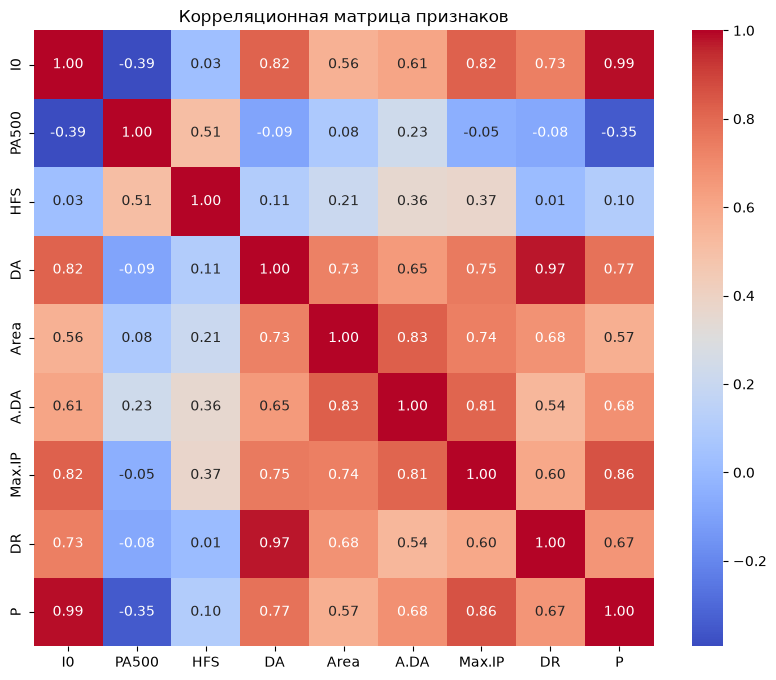

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

In [13]:
corr_pairs = corr.abs().unstack()

corr_pairs = corr_pairs[
    (corr_pairs < 1) & (corr_pairs >= 0.8)
]

print(corr_pairs.sort_values(ascending=False))

I0      P         0.988697
P       I0        0.988697
DR      DA        0.974202
DA      DR        0.974202
Max.IP  P         0.861837
P       Max.IP    0.861837
A.DA    Area      0.830172
Area    A.DA      0.830172
I0      Max.IP    0.823668
Max.IP  I0        0.823668
DA      I0        0.819606
I0      DA        0.819606
Max.IP  A.DA      0.812815
A.DA    Max.IP    0.812815
dtype: float64


In [14]:
features_reduced = [
    "I0",
    "PA500",
    "HFS",
    "DA",
    "Area",
    "Max.IP"
]

X_reduced = df[features_reduced]

print("Сокращённые признаки:")
print(X_reduced.columns.tolist())
print("Количество признаков:", X_reduced.shape[1])

Сокращённые признаки:
['I0', 'PA500', 'HFS', 'DA', 'Area', 'Max.IP']
Количество признаков: 6


In [15]:
X_reduced_train = X_reduced.loc[X_train.index]
X_reduced_test = X_reduced.loc[X_test.index]

print("Обучающая выборка:", X_reduced_train.shape)
print("Тестовая выборка:", X_reduced_test.shape)

Обучающая выборка: (84, 6)
Тестовая выборка: (22, 6)


In [16]:
scaler_reduced = StandardScaler()

X_reduced_train_scaled = scaler_reduced.fit_transform(X_reduced_train)
X_reduced_test_scaled = scaler_reduced.transform(X_reduced_test)

print("Масштабирование сокращённого набора выполнено")

Масштабирование сокращённого набора выполнено


In [17]:
model_reduced = LogisticRegression(max_iter=1000)

model_reduced.fit(X_reduced_train_scaled, y_train)

print("Сокращённая модель обучена")

Сокращённая модель обучена


In [18]:
y_pred_reduced = model_reduced.predict(X_reduced_test_scaled)

accuracy_reduced = accuracy_score(y_test, y_pred_reduced)

print("Accuracy сокращённой модели:", accuracy_reduced)

print("\nClassification report:")
print(classification_report(y_test, y_pred_reduced))

Accuracy сокращённой модели: 0.6363636363636364

Classification report:
              precision    recall  f1-score   support

         adi       0.80      0.80      0.80         5
         car       0.80      1.00      0.89         4
         con       0.67      0.67      0.67         3
         fad       0.33      0.33      0.33         3
         gla       0.60      1.00      0.75         3
         mas       0.00      0.00      0.00         4

    accuracy                           0.64        22
   macro avg       0.53      0.63      0.57        22
weighted avg       0.55      0.64      0.58        22



In [19]:
results["Сокращённая модель (6 признаков)"] = accuracy_reduced

print(results)

{'Базовая модель (9 признаков)': 0.6818181818181818, 'Сокращённая модель (6 признаков)': 0.6363636363636364}


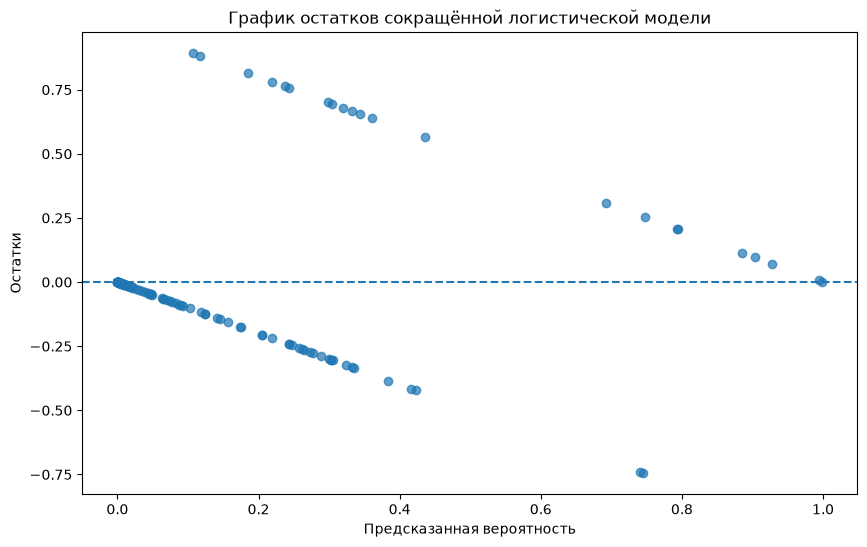

In [20]:
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# Реальные классы переводим в 0 и 1
y_test_bin = label_binarize(y_test, classes=model_reduced.classes_)

# Вероятности принадлежности к каждому классу
y_proba = model_reduced.predict_proba(X_reduced_test_scaled)

# Остатки
residuals = y_test_bin - y_proba

# График
plt.figure(figsize=(10, 6))

plt.scatter(
    y_proba.ravel(),
    residuals.ravel(),
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.xlabel("Предсказанная вероятность")
plt.ylabel("Остатки")
plt.title("График остатков сокращённой логистической модели")

plt.show()

## Итоговый вывод

В работе была построена базовая модель многоклассовой логистической регрессии с использованием всех 9 числовых признаков. Accuracy базовой модели составила 68.18%.

Для проверки мультиколлинеарности была построена корреляционная матрица. Были обнаружены сильные корреляции между некоторыми признаками: I0 и P, DA и DR, Area и A.DA, а также другими парами признаков.

После удаления части сильно коррелирующих признаков была построена сокращённая модель с 6 признаками: I0, PA500, HFS, DA, Area и Max.IP. Accuracy сокращённой модели составила 63.64%, что на 4.55 процентных пункта ниже базовой модели.

Таким образом, в данном эксперименте удаление коррелирующих признаков привело к снижению качества классификации. Поэтому для дальнейшего анализа выбран исходный набор из 9 признаков, поскольку он показал более высокую Accuracy на тестовой выборке.

Анализ графика остатков сокращённой модели показал наличие систематической структуры ошибок. Остатки не образуют полностью случайное облако вокруг нулевой линии, что указывает на наличие закономерностей в ошибках модели. При этом для многоклассовой логистической регрессии данный график является адаптированной диагностикой, поэтому классические допущения линейной регрессии напрямую к нему не применяются.

In [21]:
print("Размер датасета:", df.shape)

print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество пропусков:")
print(df.isnull().sum())

print("\nКоличество пропусков всего:", df.isnull().sum().sum())

Размер датасета: (106, 10)

Типы данных:
Class         str
I0        float64
PA500     float64
HFS       float64
DA        float64
Area      float64
A.DA      float64
Max.IP    float64
DR        float64
P         float64
dtype: object

Количество пропусков:
Class     0
I0        0
PA500     0
HFS       0
DA        0
Area      0
A.DA      0
Max.IP    0
DR        0
P         0
dtype: int64

Количество пропусков всего: 0


In [22]:
# Размер датасета
print("Размер датасета:", df.shape)

# Типы данных
print("\nТипы данных:")
print(df.dtypes)

# Пропуски
print("\nКоличество пропусков по каждому столбцу:")
print(df.isnull().sum())

print("\nВсего пропусков:", df.isnull().sum().sum())

# Основная статистика
print("\nОсновная статистика:")
print(df.describe())

# Количество объектов каждого класса
print("\nКоличество объектов по классам:")
print(df["Class"].value_counts())

# Доли классов в процентах
print("\nДоли классов:")
print(df["Class"].value_counts(normalize=True).mul(100).round(2))

Размер датасета: (106, 10)

Типы данных:
Class         str
I0        float64
PA500     float64
HFS       float64
DA        float64
Area      float64
A.DA      float64
Max.IP    float64
DR        float64
P         float64
dtype: object

Количество пропусков по каждому столбцу:
Class     0
I0        0
PA500     0
HFS       0
DA        0
Area      0
A.DA      0
Max.IP    0
DR        0
P         0
dtype: int64

Всего пропусков: 0

Основная статистика:
                I0       PA500         HFS           DA           Area  \
count   106.000000  106.000000  106.000000   106.000000     106.000000   
mean    784.251618    0.120133    0.114691   190.568642    7335.155162   
std     753.950075    0.068596    0.101347   190.801448   18580.314213   
min     103.000000    0.012392   -0.066323    19.647670      70.426239   
25%     250.000000    0.067413    0.043982    53.845470     409.647141   
50%     384.936489    0.105418    0.086568   120.777303    2219.581163   
75%    1487.989626    0.169602

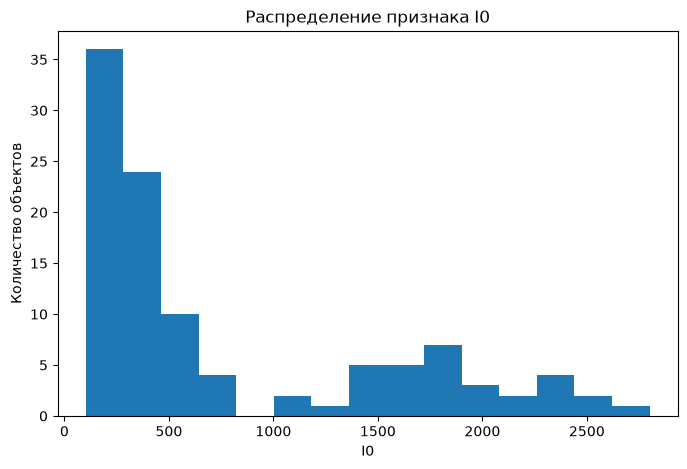

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["I0"], bins=15)

plt.xlabel("I0")
plt.ylabel("Количество объектов")
plt.title("Распределение признака I0")

plt.show()

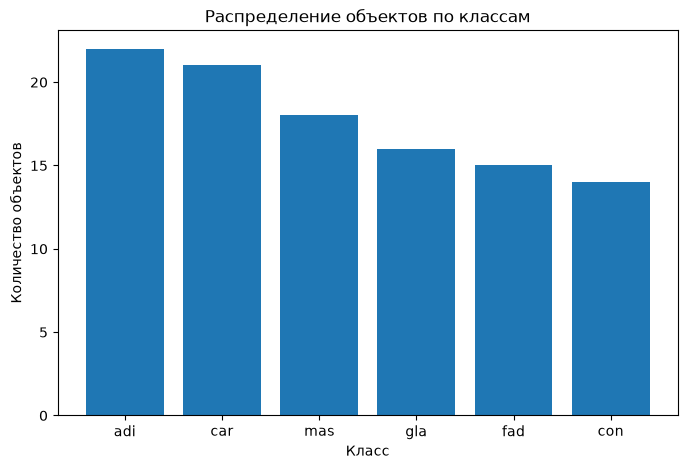

In [24]:
plt.figure(figsize=(8, 5))

class_counts = df["Class"].value_counts()

plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.title("Распределение объектов по классам")

plt.show()

## Наблюдения по данным

1. Датасет содержит 106 объектов и 9 числовых признаков, а целевая переменная Class содержит 6 различных классов.

2. В данных отсутствуют пропущенные значения, поэтому дополнительное заполнение или удаление объектов из-за пропусков не требуется.

3. Распределение классов неодинаковое: наиболее представлен класс adi (22 объекта), а наименее представлен класс con (14 объектов). Поэтому классы не являются полностью сбалансированными.

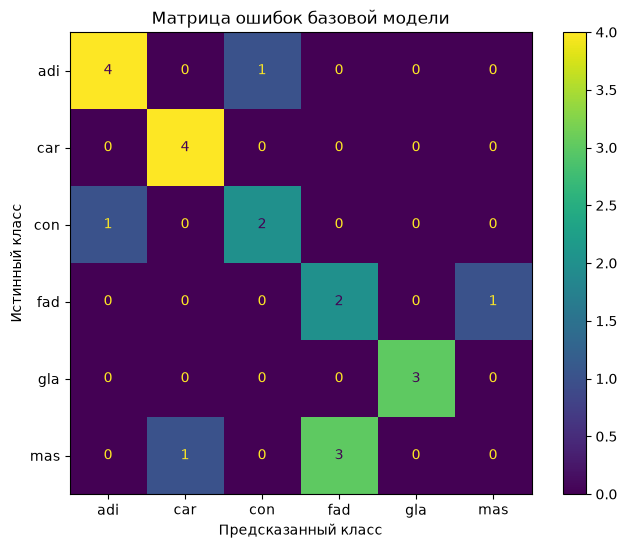

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_base, labels=model_base.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_base.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax)

ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")
ax.set_title("Матрица ошибок базовой модели")

plt.show()

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_test,
    y_pred_base,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_base,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_base,
    average="weighted"
)

print("Accuracy:", accuracy_base)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.6818181818181818
Precision: 0.609090909090909
Recall: 0.6818181818181818
F1-score: 0.6388888888888888


### Оценка качества модели

Базовая модель показала Accuracy 68.18%. 
Взвешенный Precision составил 60.91%, Recall — 68.18%, 
а F1-score — 63.89%.

Таким образом, оценка модели не ограничивается только Accuracy. 
Использование Precision, Recall и F1-score позволяет получить более 
полное представление о качестве классификации при неодинаковом 
распределении объектов между классами.